In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "data" / "output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
results = pd.read_csv(
    OUTPUT_DIR / "forecast_results.csv"
)

results["date"] = pd.to_datetime(
    results["date"]
)

In [ ]:
results.shape

(600, 7)

In [ ]:
results.head()

,date,estate_id,actual,forecast,model,error,absolute_error
0,2025-01-01,EST001,8385.6,9199.8,Naive,-814.2,814.2
1,2025-02-01,EST001,9219.1,9199.8,Naive,19.3,19.3
2,2025-03-01,EST001,8661.8,9199.8,Naive,-538.0,538.0
3,2025-04-01,EST001,10508.3,9199.8,Naive,1308.5,1308.5
4,2025-05-01,EST001,10733.9,9199.8,Naive,1534.1,1534.1


## Cek Model yang Tersedia

In [ ]:
results["model"].unique()

array(['Naive', 'Seasonal Naive', 'Holt-Winters', 'SARIMA',
       'Random Forest'], dtype=object)

In [ ]:
results.groupby("model").size()

,0
model,
Holt-Winters,120
Naive,120
Random Forest,120
SARIMA,120
Seasonal Naive,120


## Evaluation Function

In [ ]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

## Overall Model Evaluation

In [ ]:
overall_metrics = []

for model_name, group in results.groupby("model"):

    metrics = calculate_metrics(
        group["actual"],
        group["forecast"]
    )

    overall_metrics.append({
        "model": model_name,
        **metrics
    })

In [ ]:
overall_metrics = pd.DataFrame(
    overall_metrics
)

In [ ]:
overall_metrics

,model,MAE,RMSE,MAPE
0,Holt-Winters,788.138302,1001.911148,8.430236
1,Naive,975.953333,1228.357482,9.902923
2,Random Forest,160.650625,255.661940,1.648470
3,SARIMA,13765.835901,41841.305267,147.536486
4,Seasonal Naive,824.109583,1036.151644,8.651075


In [ ]:
overall_metrics.sort_values(
    "MAPE"
)

,model,MAE,RMSE,MAPE
2,Random Forest,160.650625,255.661940,1.648470
0,Holt-Winters,788.138302,1001.911148,8.430236
4,Seasonal Naive,824.109583,1036.151644,8.651075
1,Naive,975.953333,1228.357482,9.902923
3,SARIMA,13765.835901,41841.305267,147.536486


## Visualize Overall Model Performance

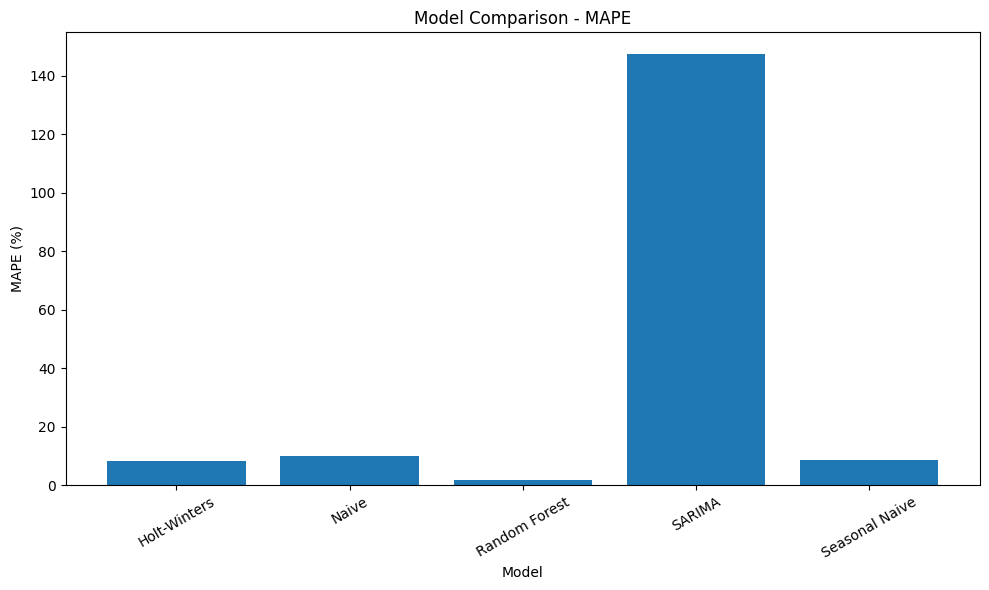

In [ ]:
# mape
plt.figure(figsize=(10, 6))

plt.bar(
    overall_metrics["model"],
    overall_metrics["MAPE"]
)

plt.title("Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

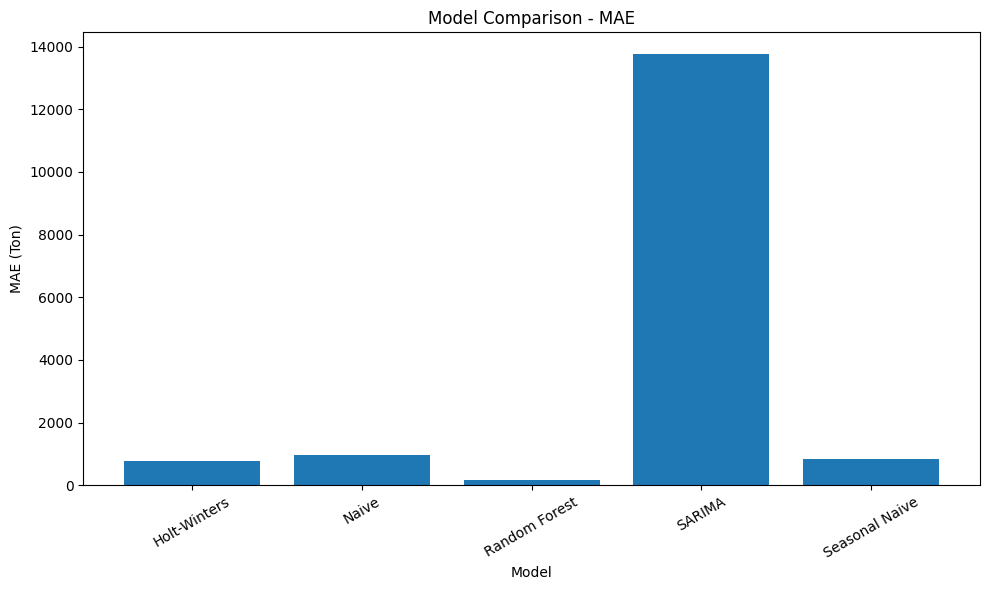

In [ ]:
# mae
plt.figure(figsize=(10, 6))

plt.bar(
    overall_metrics["model"],
    overall_metrics["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE (Ton)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

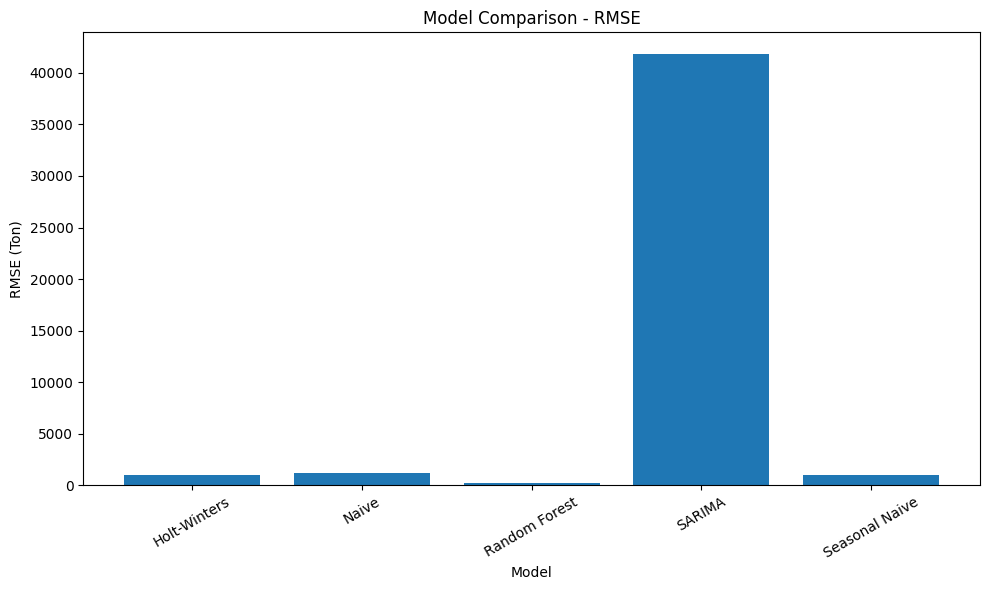

In [ ]:
# rmse
plt.figure(figsize=(10, 6))

plt.bar(
    overall_metrics["model"],
    overall_metrics["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (Ton)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Evaluasi Per Estate

In [ ]:
estate_metrics = []

for (model_name, estate_id), group in results.groupby(
    ["model", "estate_id"]
):

    metrics = calculate_metrics(
        group["actual"],
        group["forecast"]
    )

    estate_metrics.append({
        "model": model_name,
        "estate_id": estate_id,
        **metrics
    })

In [ ]:
estate_metrics = pd.DataFrame(
    estate_metrics
)

In [ ]:
estate_metrics.head()

,model,estate_id,MAE,RMSE,MAPE
0,Holt-Winters,EST001,673.537661,988.531398,7.771740
1,Holt-Winters,EST002,726.004397,937.029576,9.359850
2,Holt-Winters,EST003,769.308152,921.189638,7.397405
3,Holt-Winters,EST004,665.659309,818.315979,6.272505
4,Holt-Winters,EST005,978.179659,1198.754913,7.872159


## MAPE Per Estate

In [ ]:
estate_mape = estate_metrics.pivot(
    index="estate_id",
    columns="model",
    values="MAPE"
)

estate_mape

model,Holt-Winters,Naive,Random Forest,SARIMA,Seasonal Naive
estate_id,,,,,
EST001,7.771740,9.082220,2.522454,1391.930114,11.825276
EST002,9.359850,8.256994,2.086076,8.348666,8.119517
EST003,7.397405,4.326458,0.827672,7.237228,6.781747
EST004,6.272505,11.525500,1.219272,4.938820,8.999747
EST005,7.872159,8.020787,2.689080,9.813310,7.490293
EST006,9.245145,17.598105,1.091163,14.339116,7.544245
EST007,4.048146,8.699373,1.332419,8.752406,7.272143
EST008,8.009996,9.499358,1.667858,8.729934,9.343998
EST009,8.210630,17.094732,1.537200,9.791467,9.829303


## Visualize Estate-Level Performance

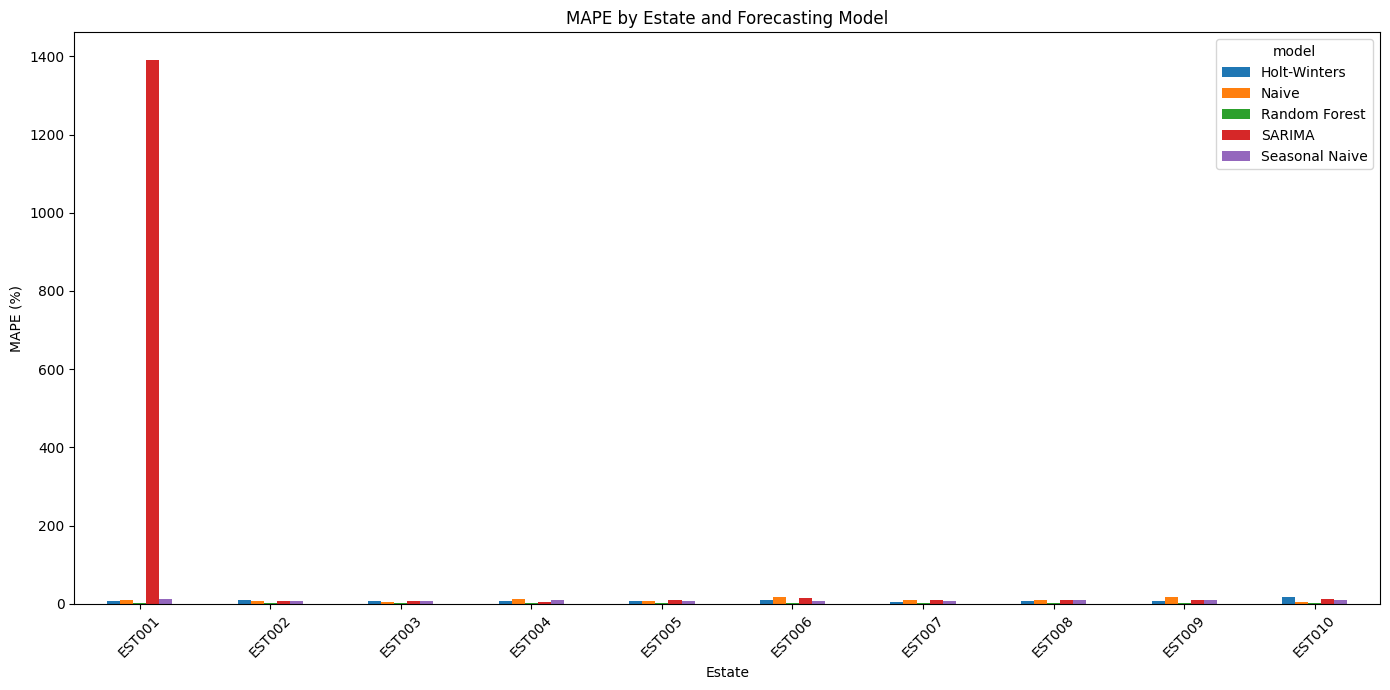

In [ ]:
estate_mape.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("MAPE by Estate and Forecasting Model")
plt.xlabel("Estate")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## MAE Per Estate

In [ ]:
estate_mae = estate_metrics.pivot(
    index="estate_id",
    columns="model",
    values="MAE"
)

estate_mae

model,Holt-Winters,Naive,Random Forest,SARIMA,Seasonal Naive
estate_id,,,,,
EST001,673.537661,849.483333,212.965778,129651.838973,1069.791667
EST002,726.004397,707.241667,164.878724,652.374187,646.966667
EST003,769.308152,462.616667,86.906239,759.390471,705.604167
EST004,665.659309,1306.966667,137.868280,532.105879,993.283333
EST005,978.179659,1044.350000,350.328136,1231.080320,928.812500
EST006,864.350649,1729.670833,105.232330,1357.618949,717.633333
EST007,411.802109,955.200000,144.816854,916.338670,752.491667
EST008,735.985419,957.337500,151.171764,778.793352,853.637500
EST009,592.700459,1310.283333,113.882877,737.580477,732.458333


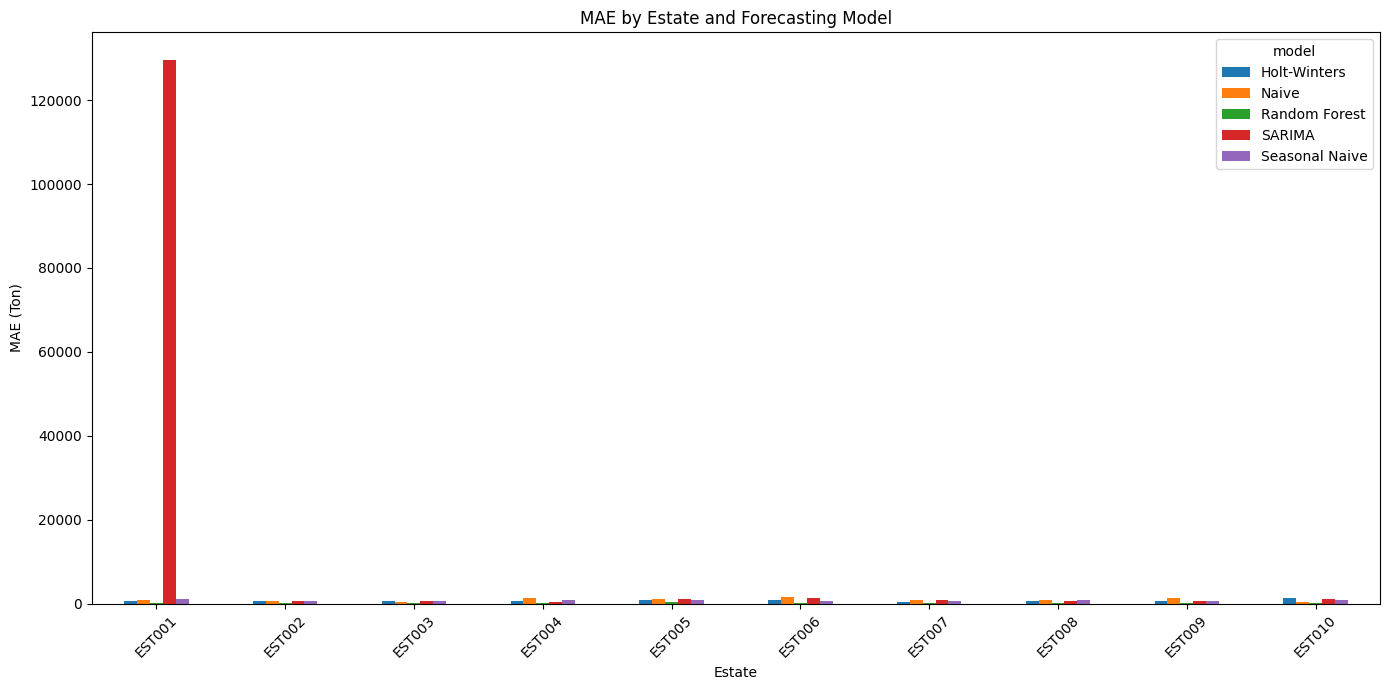

In [ ]:
estate_mae.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("MAE by Estate and Forecasting Model")
plt.xlabel("Estate")
plt.ylabel("MAE (Ton)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Monthly Forecast Error

In [ ]:
results["error"] = (
    results["actual"] -
    results["forecast"]
)

results["absolute_error"] = (
    results["error"].abs()
)

In [ ]:
monthly_error = (
    results
    .groupby(["date", "model"])
    ["absolute_error"]
    .mean()
    .reset_index()
)

## Plot Monthly Error

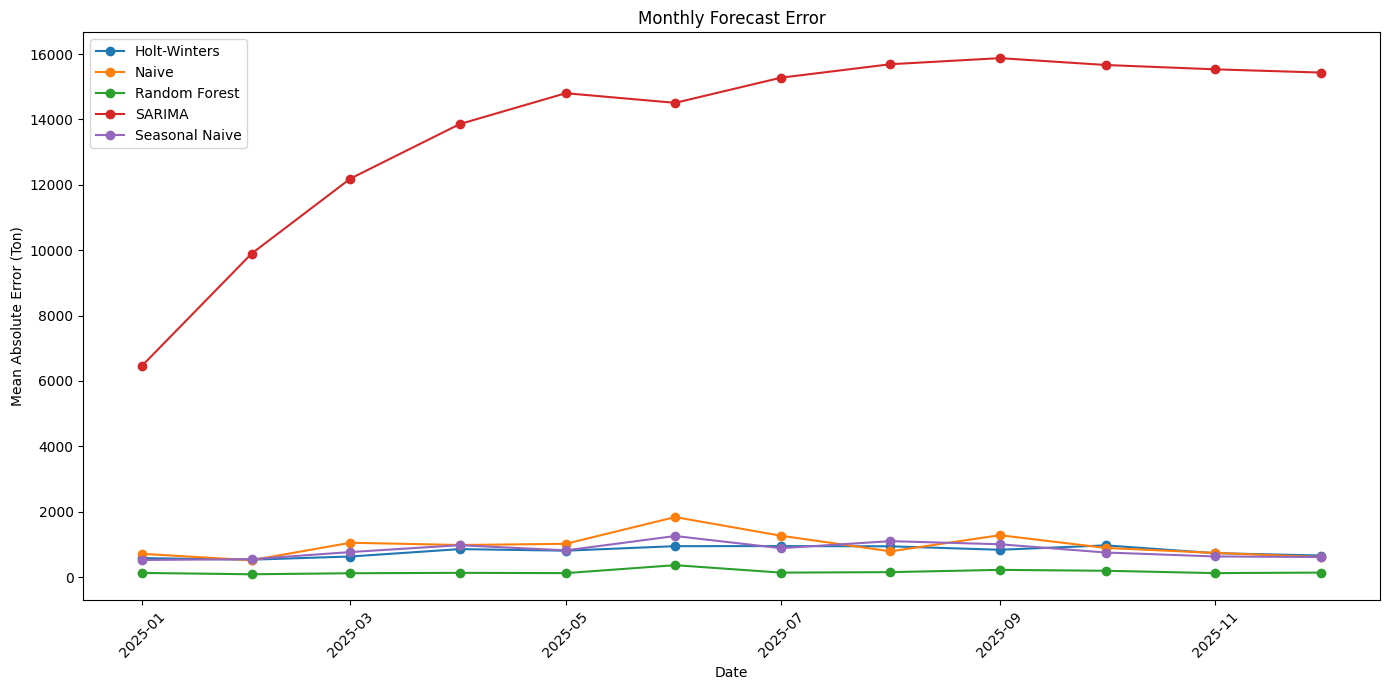

In [ ]:
plt.figure(figsize=(14, 7))

for model_name in monthly_error["model"].unique():

    model_data = monthly_error[
        monthly_error["model"] == model_name
    ]

    plt.plot(
        model_data["date"],
        model_data["absolute_error"],
        marker="o",
        label=model_name
    )

plt.title("Monthly Forecast Error")
plt.xlabel("Date")
plt.ylabel("Mean Absolute Error (Ton)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Forecast Bias
#### error = actual - forecast
#### error > 0
- actual > forecast
- model underforecast
#### error < 0
- actual < forecast
- model overforecast

In [ ]:
bias_summary = (
    results
    .groupby("model")["error"]
    .mean()
    .reset_index(name="mean_error")
)

bias_summary

,model,mean_error
0,Holt-Winters,-467.292062
1,Naive,643.046667
2,Random Forest,-21.826972
3,SARIMA,12522.980411
4,Seasonal Naive,-243.399583


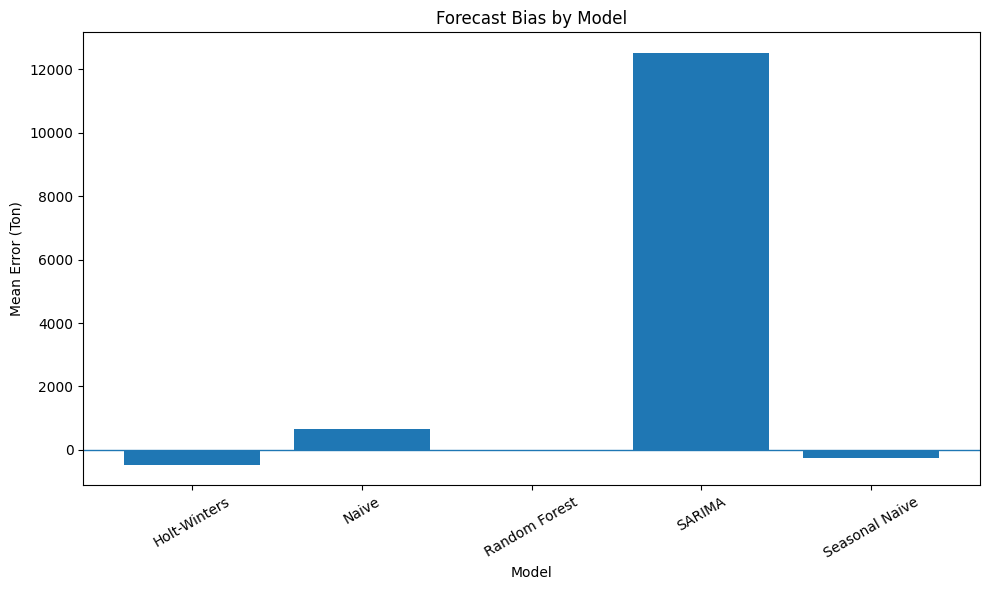

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    bias_summary["model"],
    bias_summary["mean_error"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Forecast Bias by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error (Ton)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Positive bias: cenderung underforecast
# Negative bias: cenderung overforecast

## Actual vs Forecast

In [ ]:
selected_estate = results[
    "estate_id"
].iloc[0]

print(selected_estate)

EST001


In [ ]:
estate_results = results[
    results["estate_id"] == selected_estate
]

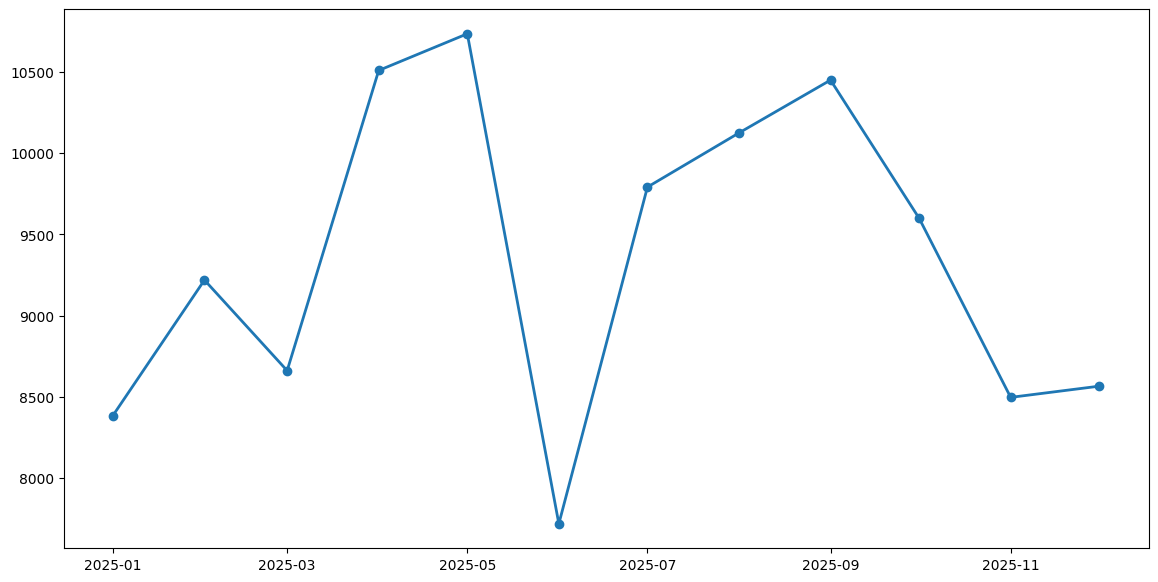

In [ ]:
plt.figure(figsize=(14, 7))

actual_data = (
    estate_results[
        estate_results["model"] == "Naive"
    ]
)

plt.plot(
    actual_data["date"],
    actual_data["actual"],
    marker="o",
    linewidth=2,
    label="Actual"
)

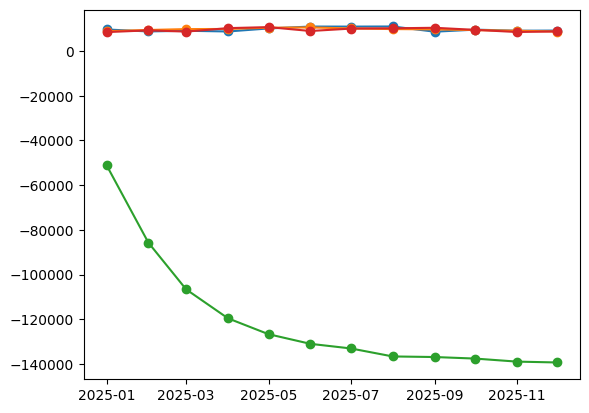

In [ ]:
for model_name in [
    "Seasonal Naive",
    "Holt-Winters",
    "SARIMA",
    "Random Forest"
]:

    model_data = estate_results[
        estate_results["model"] == model_name
    ]

    plt.plot(
        model_data["date"],
        model_data["forecast"],
        marker="o",
        label=model_name
    )

/tmp/ipykernel_1431/2312963494.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


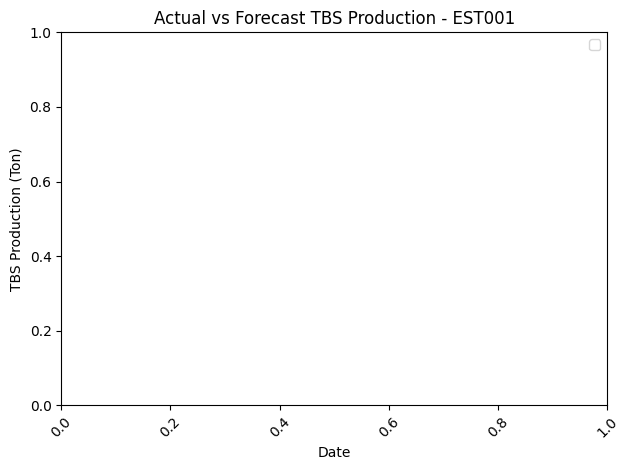

In [ ]:
plt.title(
    f"Actual vs Forecast TBS Production - {selected_estate}"
)

plt.xlabel("Date")
plt.ylabel("TBS Production (Ton)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Residual Analysis

In [ ]:
results["residual"] = (
    results["actual"] -
    results["forecast"]
)

In [ ]:
rf_results = results[
    results["model"] == "Random Forest"
]

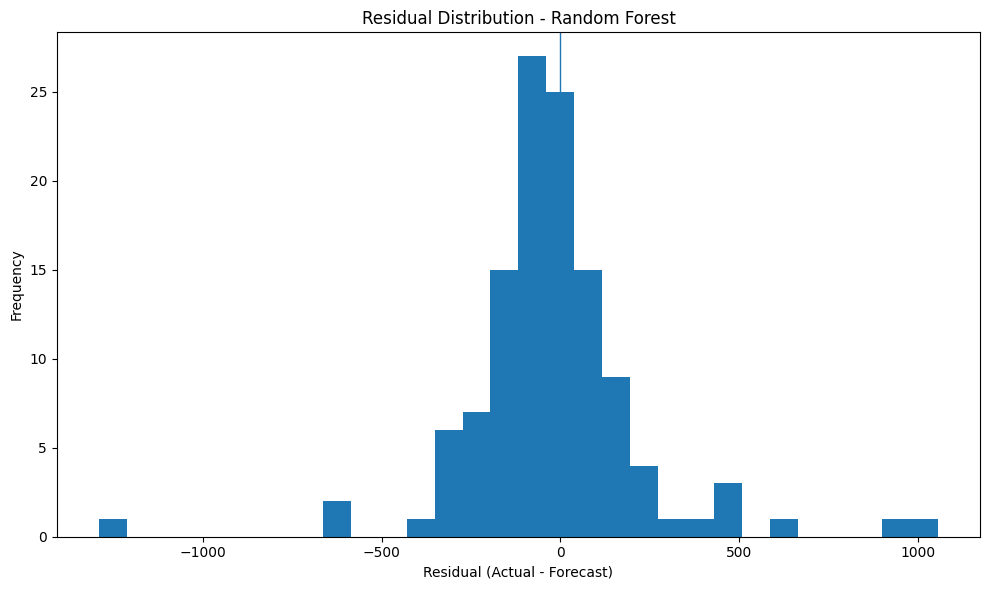

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    rf_results["residual"],
    bins=30
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Residual Distribution - Random Forest")
plt.xlabel("Residual (Actual - Forecast)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Residual vs Actual

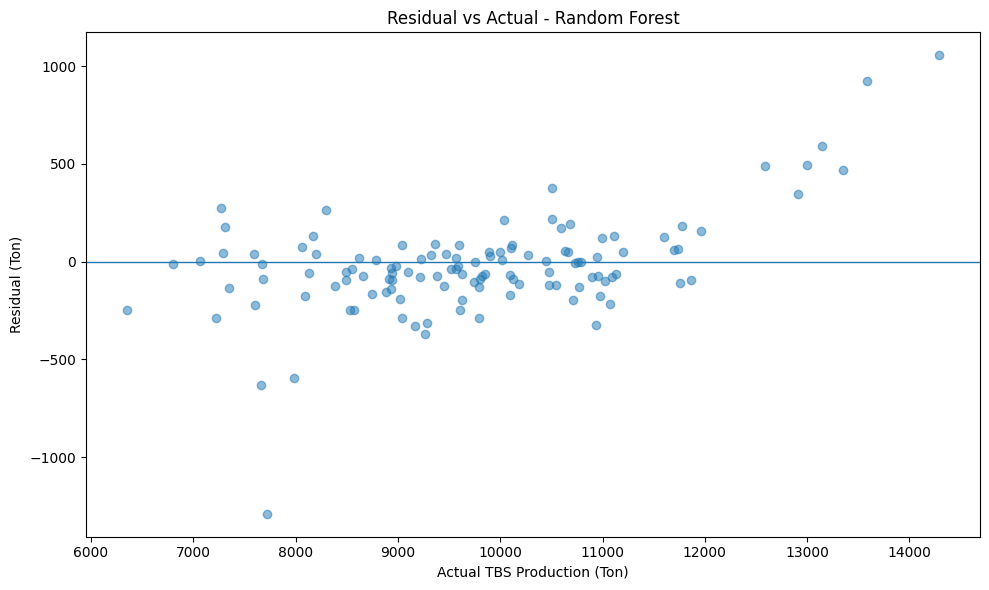

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rf_results["actual"],
    rf_results["residual"],
    alpha=0.5
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Residual vs Actual - Random Forest")
plt.xlabel("Actual TBS Production (Ton)")
plt.ylabel("Residual (Ton)")

plt.tight_layout()
plt.show()

## MAPE Per Month

In [ ]:
results["absolute_percentage_error"] = (
    np.abs(
        (results["actual"] - results["forecast"])
        / results["actual"]
    ) * 100
)

In [ ]:
monthly_mape = (
    results
    .groupby(["date", "model"])
    ["absolute_percentage_error"]
    .mean()
    .reset_index()
)

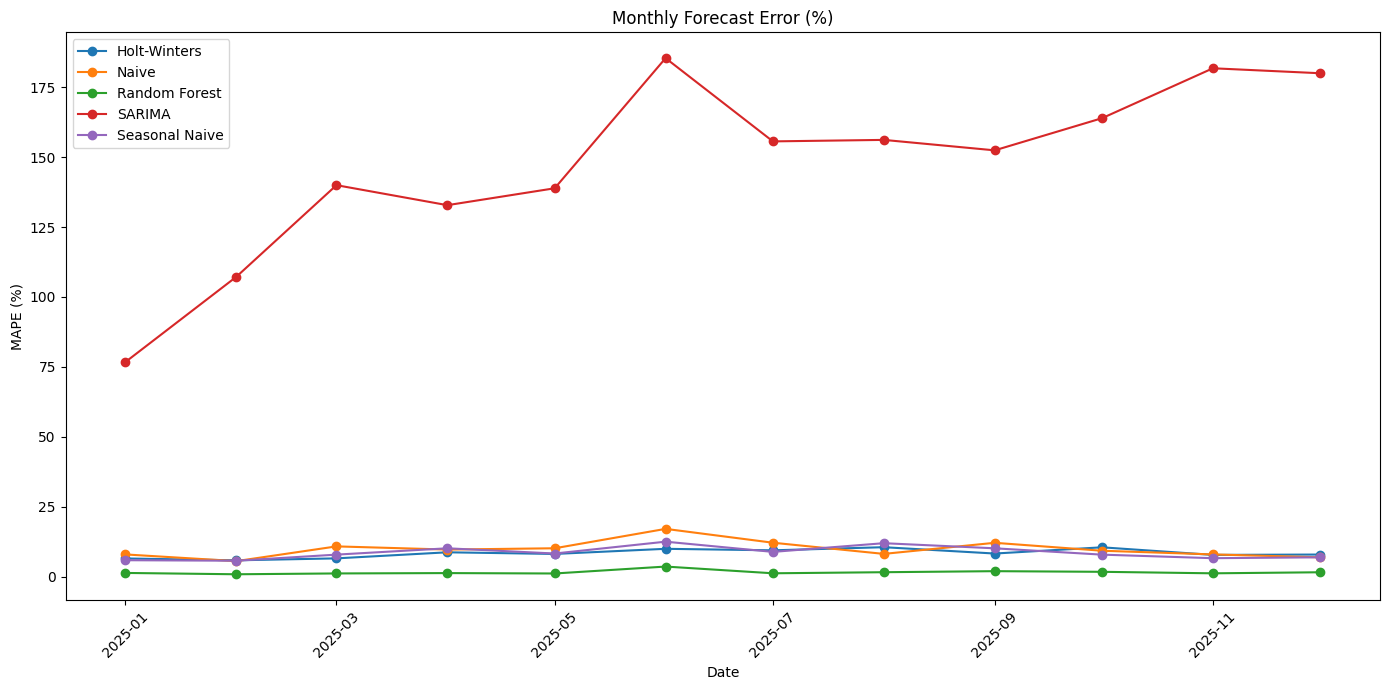

In [ ]:
plt.figure(figsize=(14, 7))

for model_name in monthly_mape["model"].unique():

    model_data = monthly_mape[
        monthly_mape["model"] == model_name
    ]

    plt.plot(
        model_data["date"],
        model_data["absolute_percentage_error"],
        marker="o",
        label=model_name
    )

plt.title("Monthly Forecast Error (%)")
plt.xlabel("Date")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Model Performance by Region

In [ ]:
BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
estate_master = pd.read_csv(
    PROCESSED_DIR / "estate_master_cleaned.csv"
)

In [ ]:
results = results.merge(
    estate_master[
        [
            "estate_id",
            "estate_name",
            "region"
        ]
    ],
    on="estate_id",
    how="left"
)

In [ ]:
results[
    [
        "estate_id",
        "estate_name",
        "region"
    ]
].drop_duplicates()

,estate_id,estate_name,region
0,EST001,Estate Lampung 01,Sumatra
12,EST002,Estate Lampung 02,Sumatra
24,EST003,Estate Sumsel 01,Sumatra
36,EST004,Estate Jambi 01,Sumatra
48,EST005,Estate Riau 01,Sumatra
60,EST006,Estate Kalbar 01,Kalimantan
72,EST007,Estate Kalteng 01,Kalimantan
84,EST008,Estate Kaltim 01,Kalimantan
96,EST009,Estate Sulawesi 01,Sulawesi
108,EST010,Estate Sulawesi 02,Sulawesi


## Regional Performance

In [ ]:
regional_metrics = []

for (model_name, region), group in results.groupby(
    ["model", "region"]
):

    metrics = calculate_metrics(
        group["actual"],
        group["forecast"]
    )

    regional_metrics.append({
        "model": model_name,
        "region": region,
        **metrics
    })

In [ ]:
regional_metrics = pd.DataFrame(
    regional_metrics
)

In [ ]:
regional_metrics

,model,region,MAE,RMSE,MAPE
0,Holt-Winters,Kalimantan,670.712726,901.839277,7.101096
1,Holt-Winters,Sulawesi,1028.277832,1180.646807,12.162708
2,Holt-Winters,Sumatra,762.537835,980.863240,7.734732
3,Naive,Kalimantan,1214.069444,1447.874211,11.932279
4,Naive,Sulawesi,873.333333,1075.726498,11.010215
5,Naive,Sumatra,874.131667,1138.878996,8.242392
6,Random Forest,Kalimantan,133.740316,185.632601,1.363814
7,Random Forest,Sulawesi,126.169073,167.041842,1.524355
8,Random Forest,Sumatra,190.589431,314.466511,1.868911
9,SARIMA,Kalimantan,1017.583657,1280.686158,10.607152


## Regional MAPE

In [ ]:
regional_mape = regional_metrics.pivot(
    index="region",
    columns="model",
    values="MAPE"
)

regional_mape

model,Holt-Winters,Naive,Random Forest,SARIMA,Seasonal Naive
region,,,,,
Kalimantan,7.101096,11.932279,1.363814,10.607152,8.053462
Sulawesi,12.162708,11.010215,1.524355,10.637635,9.566893
Sumatra,7.734732,8.242392,1.868911,284.453628,8.643316


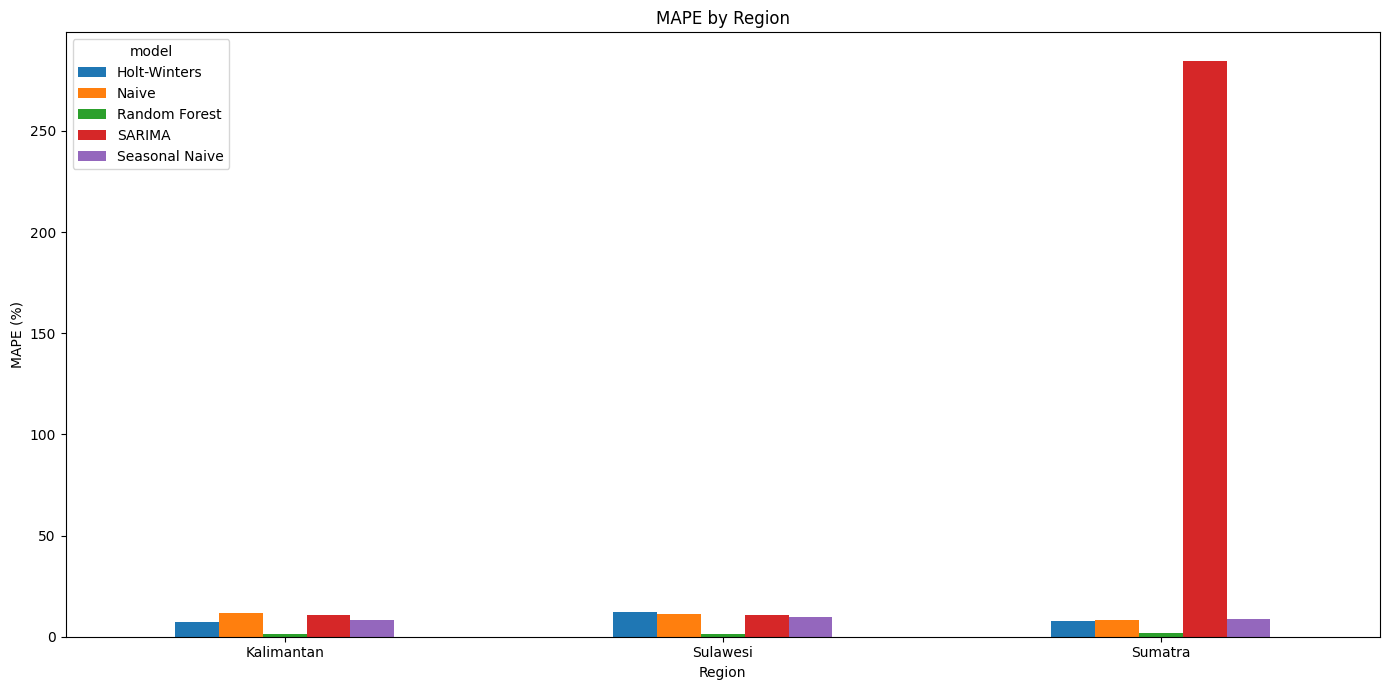

In [ ]:
regional_mape.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("MAPE by Region")
plt.xlabel("Region")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Error Distribution Per Model

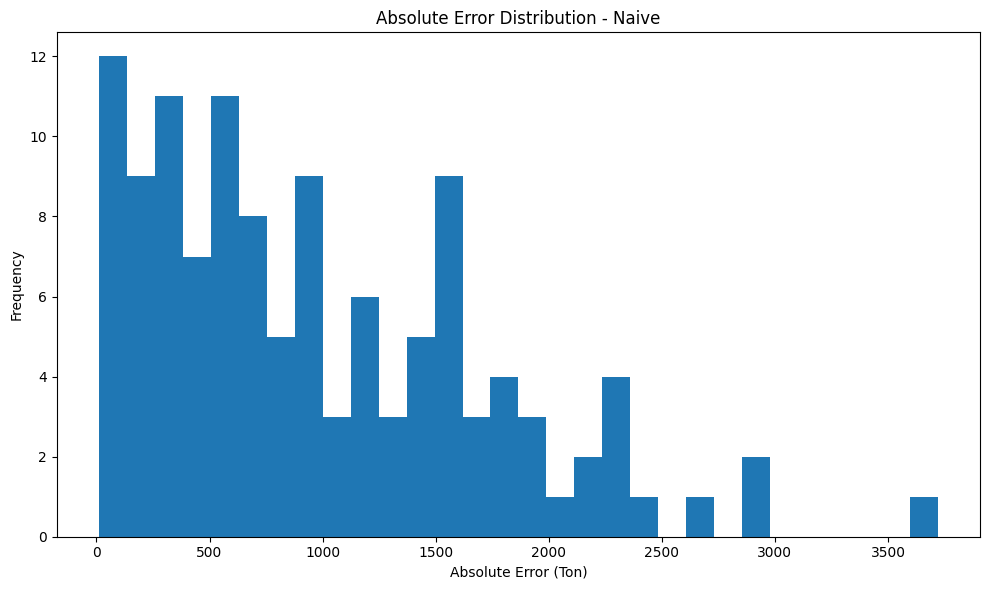

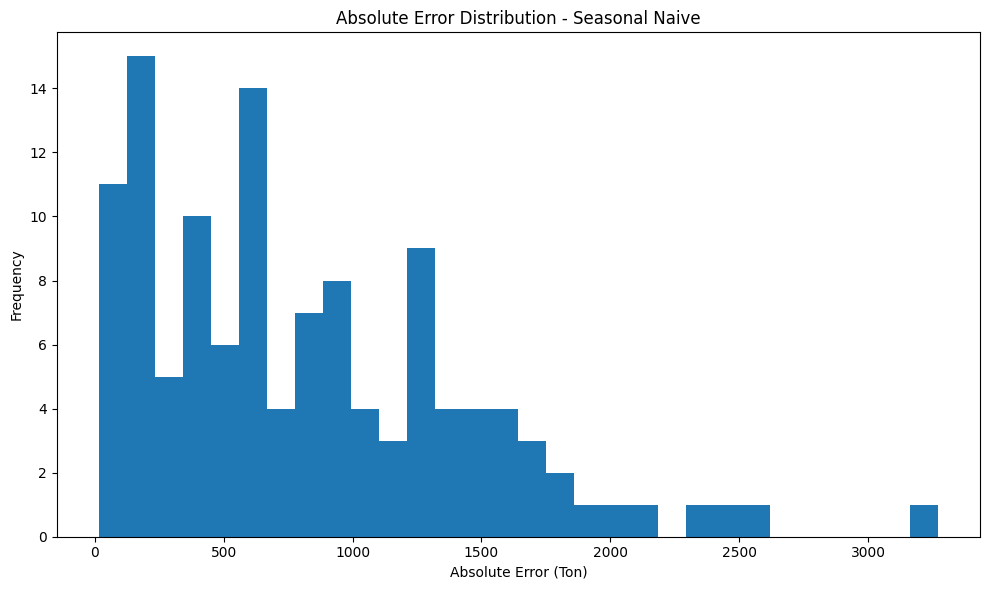

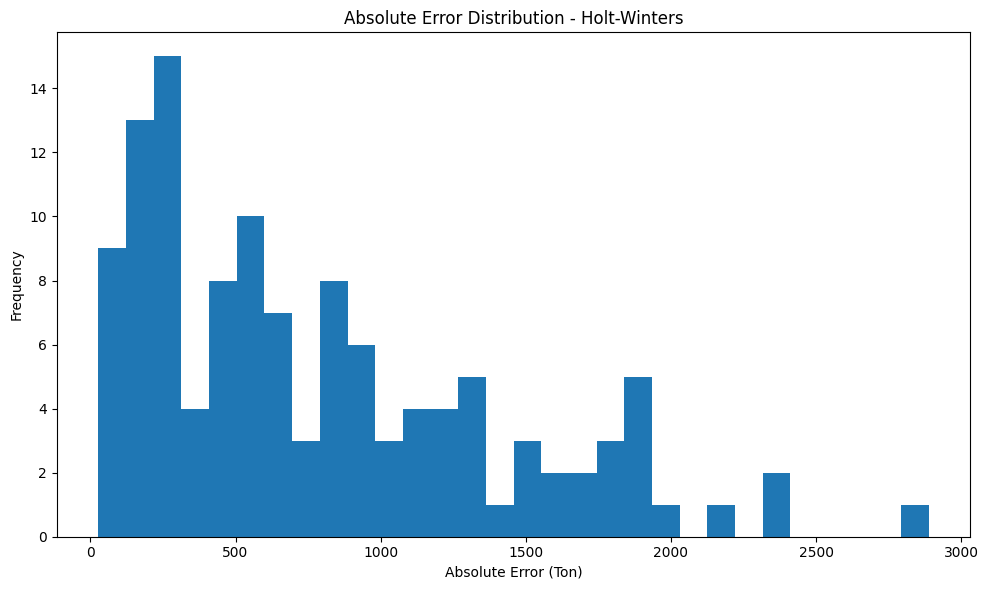

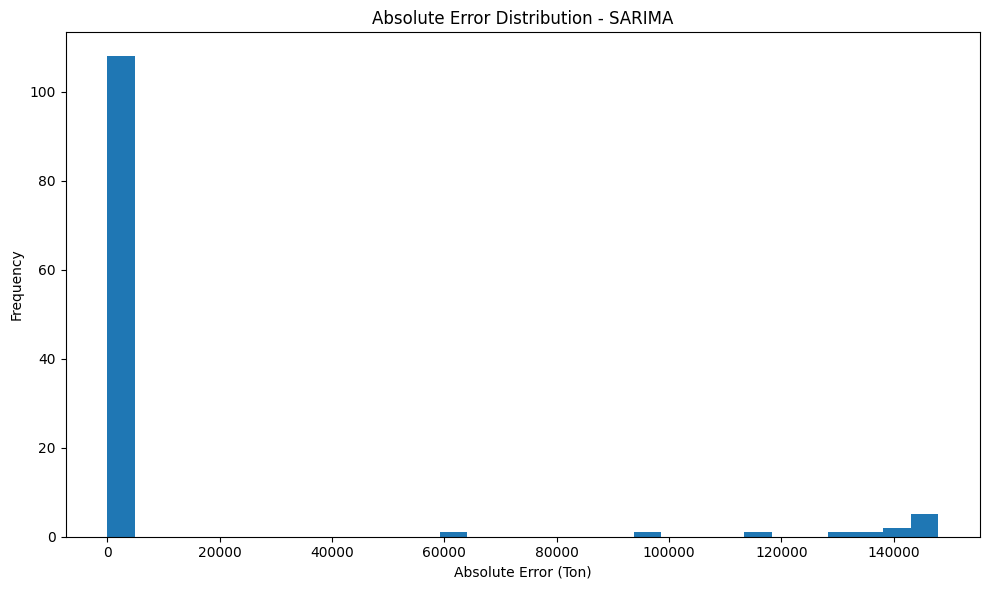

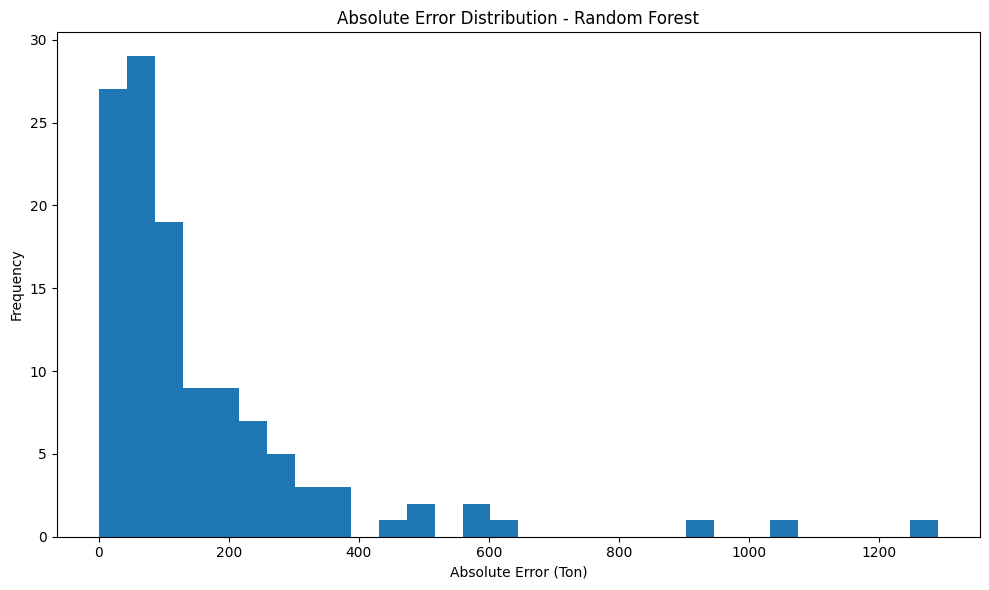

In [ ]:
models = results["model"].unique()

for model_name in models:

    model_data = results[
        results["model"] == model_name
    ]

    plt.figure(figsize=(10, 6))

    plt.hist(
        model_data["absolute_error"],
        bins=30
    )

    plt.title(
        f"Absolute Error Distribution - {model_name}"
    )

    plt.xlabel("Absolute Error (Ton)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## Cari Bulan dengan Error Tertinggi
> nanti bisa membantu menjawab: kapan forecasting paling sulit?

In [ ]:
rf_monthly_error = (
    results[
        results["model"] == "Random Forest"
    ]
    .groupby("date")
    ["absolute_error"]
    .mean()
    .sort_values(
        ascending=False
    )
)

rf_monthly_error.head(10)

,absolute_error
date,
2025-06-01,366.290359
2025-09-01,222.781719
2025-10-01,194.638498
2025-08-01,153.267980
2025-12-01,139.400122
2025-07-01,138.396967
2025-04-01,131.164506
2025-01-01,128.839816
2025-11-01,123.174721


## Cari Estate dengan Error Tertinggi

In [ ]:
rf_estate_error = (
    results[
        results["model"] == "Random Forest"
    ]
    .groupby("estate_id")
    ["absolute_error"]
    .mean()
    .sort_values(
        ascending=False
    )
)

rf_estate_error

,absolute_error
estate_id,
EST005,350.328136
EST001,212.965778
EST002,164.878724
EST008,151.171764
EST007,144.816854
EST010,138.455268
EST004,137.868280
EST009,113.882877
EST006,105.232330


## Model Comparison Final

In [ ]:
final_comparison = (
    overall_metrics
    .sort_values("MAPE")
    .reset_index(drop=True)
)

final_comparison

,model,MAE,RMSE,MAPE
0,Random Forest,160.650625,255.661940,1.648470
1,Holt-Winters,788.138302,1001.911148,8.430236
2,Seasonal Naive,824.109583,1036.151644,8.651075
3,Naive,975.953333,1228.357482,9.902923
4,SARIMA,13765.835901,41841.305267,147.536486


## Simpan Evaluation Results

In [ ]:
OUTPUT_DIR = Path("data/output")

overall_metrics.to_csv(
    OUTPUT_DIR / "overall_model_evaluation.csv",
    index=False
)

estate_metrics.to_csv(
    OUTPUT_DIR / "estate_model_evaluation.csv",
    index=False
)

regional_metrics.to_csv(
    OUTPUT_DIR / "regional_model_evaluation.csv",
    index=False
)

In [ ]:
results.to_csv(
    OUTPUT_DIR / "forecast_results_evaluated.csv",
    index=False
)

## Evaluation Summary

In [ ]:
print("=" * 60)
print("FORECASTING MODEL EVALUATION SUMMARY")
print("=" * 60)

print("\nOverall Performance:")
display(final_comparison)

print("\nEstate-Level Evaluation:")
display(
    estate_metrics.head(10)
)

print("\nRegional Evaluation:")
display(
    regional_metrics
)

FORECASTING MODEL EVALUATION SUMMARY

Overall Performance:


,model,MAE,RMSE,MAPE
0,Random Forest,160.650625,255.661940,1.648470
1,Holt-Winters,788.138302,1001.911148,8.430236
2,Seasonal Naive,824.109583,1036.151644,8.651075
3,Naive,975.953333,1228.357482,9.902923
4,SARIMA,13765.835901,41841.305267,147.536486



Estate-Level Evaluation:


,model,estate_id,MAE,RMSE,MAPE
0,Holt-Winters,EST001,673.537661,988.531398,7.771740
1,Holt-Winters,EST002,726.004397,937.029576,9.359850
2,Holt-Winters,EST003,769.308152,921.189638,7.397405
3,Holt-Winters,EST004,665.659309,818.315979,6.272505
4,Holt-Winters,EST005,978.179659,1198.754913,7.872159
5,Holt-Winters,EST006,864.350649,1150.171043,9.245145
6,Holt-Winters,EST007,411.802109,519.345743,4.048146
7,Holt-Winters,EST008,735.985419,920.504651,8.009996
8,Holt-Winters,EST009,592.700459,704.680619,8.210630
9,Holt-Winters,EST010,1463.855205,1513.697126,16.114786



Regional Evaluation:


,model,region,MAE,RMSE,MAPE
0,Holt-Winters,Kalimantan,670.712726,901.839277,7.101096
1,Holt-Winters,Sulawesi,1028.277832,1180.646807,12.162708
2,Holt-Winters,Sumatra,762.537835,980.863240,7.734732
3,Naive,Kalimantan,1214.069444,1447.874211,11.932279
4,Naive,Sulawesi,873.333333,1075.726498,11.010215
5,Naive,Sumatra,874.131667,1138.878996,8.242392
6,Random Forest,Kalimantan,133.740316,185.632601,1.363814
7,Random Forest,Sulawesi,126.169073,167.041842,1.524355
8,Random Forest,Sumatra,190.589431,314.466511,1.868911
9,SARIMA,Kalimantan,1017.583657,1280.686158,10.607152


In [ ]:
rf_check = results[
    results["model"] == "Random Forest"
][
    ["date", "estate_id", "actual", "forecast", "absolute_error"]
].copy()

print(rf_check.head(20))

          date estate_id   actual      forecast  absolute_error
480 2025-01-01    EST001   8385.6   8511.103005      125.503005
481 2025-02-01    EST001   9219.1   9295.416363       76.316363
482 2025-03-01    EST001   8661.8   8733.641644       71.841644
483 2025-04-01    EST001  10508.3  10290.192226      218.107774
484 2025-05-01    EST001  10733.9  10741.913551        8.013551
485 2025-06-01    EST001   7719.9   9010.199718     1290.299718
486 2025-07-01    EST001   9791.0  10080.444097      289.444097
487 2025-08-01    EST001  10124.1  10212.086874       87.986874
488 2025-09-01    EST001  10449.1  10447.380097        1.719903
489 2025-10-01    EST001   9599.1   9514.896718       84.203282
490 2025-11-01    EST001   8497.5   8552.965916       55.465916
491 2025-12-01    EST001   8566.4   8813.087215      246.687215
492 2025-01-01    EST002   8203.5   8165.294731       38.205269
493 2025-02-01    EST002   8135.0   8194.477365       59.477365
494 2025-03-01    EST002   9223.9   9208